In [3]:
# ==========================================
# Cell 1 - Install Required Libraries
# ==========================================

!pip -q install hazm sentence-transformers gensim scikit-learn kagglehub

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.2/887.2 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.7 MB/s eta 0:00:00


In [4]:
# ==========================================
# Cell 2 - Import Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hazm import Normalizer, word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

from sentence_transformers import SentenceTransformer

import kagglehub

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [5]:
# ==========================================
# Cell 3 - Install Dataset Creation Libraries
# ==========================================

!pip -q install wikipedia-api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 10.1 MB/s eta 0:00:00


In [6]:
# ==========================================
# Cell 4 - Import Dataset Creation Libraries
# ==========================================

import wikipediaapi
import pandas as pd
import re

print("Dataset tools imported successfully.")

Dataset tools imported successfully.


In [7]:
# ==========================================
# Cell 5 - Connect To Persian Wikipedia
# ==========================================

wiki = wikipediaapi.Wikipedia(
    language="fa",
    user_agent="Persian_Text_Embedding_Project"
)

print("Connected to Persian Wikipedia.")

Connected to Persian Wikipedia.


In [8]:
# ==========================================
# Cell 6 - Define Persian Topics
# ==========================================

topics = [
    "هوش مصنوعی",
    "یادگیری ماشین",
    "علوم کامپیوتر",
    "ریاضیات",
    "جبر خطی",
    "فیزیک",
    "مهندسی",
    "رباتیک",
    "شبکه عصبی",
    "پردازش زبان طبیعی",
    "دانشگاه",
    "اقتصاد",
    "پزشکی",
    "تاریخ",
    "فناوری"
]


print("Number of Topics:", len(topics))

Number of Topics: 15


In [9]:
# ==========================================
# Cell 7 - Extract Wikipedia Texts
# ==========================================

texts = []

for topic in topics:

    page = wiki.page(topic)

    if page.exists():

        content = page.text

        texts.append(content)


print("Collected Pages:", len(texts))

Collected Pages: 15


In [10]:
# ==========================================
# Cell 8 - Split Into Sentences
# ==========================================

sentences = []

for text in texts:

    parts = re.split(r'[.!؟\n]', text)

    for p in parts:

        p = p.strip()

        if len(p) > 30:
            sentences.append(p)


print("Number of Sentences:", len(sentences))

Number of Sentences: 1827


In [12]:
# ==========================================
# Cell 9 - Save Dataset
# ==========================================

df = pd.DataFrame({
    "text": sentences
})


df.to_csv(
    "dataset/persian_texts.csv",
    index=False,
    encoding="utf-8-sig"
)


print("Dataset Saved Successfully.")
print(df.shape)

Dataset Saved Successfully.
(1827, 1)


In [13]:
# ==========================================
# Cell 10 - Load Final Dataset
# ==========================================

import pandas as pd

df = pd.read_csv(
    "dataset/persian_texts.csv",
    encoding="utf-8-sig"
)


print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1827, 1)


,text
0,هوش مصنوعی (به انگلیسی: Artificial intelligenc...
1,ولی پیش از هرچیز باید این موضوع را دانست که کل...
2,کتاب‌های هوش مصنوعی پیشرو، این شاخه را به عنوا...
3,برخی از منابع شناخته شده از اصطلاح «هوش مصنوعی...
4,کاربردهای هوش مصنوعی شامل موتورهای جستجو پیشرف...


In [14]:
# ==========================================
# Cell 11 - Dataset Inspection
# ==========================================

print("Missing Values:")
print(df.isnull().sum())


print("\nAverage Text Length:")

print(
    df["text"].str.len().mean()
)

Missing Values:
text    0
dtype: int64

Average Text Length:
126.31417624521073


In [15]:
# ==========================================
# Cell 12 - Remove Duplicates
# ==========================================

df = df.drop_duplicates(
    subset=["text"]
)


df = df.reset_index(drop=True)


print("New Shape:")
print(df.shape)

New Shape:
(1812, 1)


In [16]:
# ==========================================
# Cell 13 - Create Text List
# ==========================================

texts = df["text"].tolist()


print("Number of Texts:", len(texts))


print("\nExample:")

print(texts[0])

Number of Texts: 1812

Example:
هوش مصنوعی (به انگلیسی: Artificial intelligence) (سَرنام انگلیسی: AI)، که در برخی منابع علمی هوشواره نیز نامیده می‌شود، هوشی است که به‌دست ماشین‌ها پدید می‌آید، در برابر هوش طبیعی که توسط جانوران شامل انسان‌ها نمایش می‌یابد


In [17]:
# ==========================================
# Cell 14 - Install Hazm
# ==========================================

!pip -q install hazm

In [18]:
# ==========================================
# Cell 15 - Advanced Persian Text Cleaning
# ==========================================

from hazm import Normalizer
import re


normalizer = Normalizer()


def clean_text(text):

    # Persian normalization
    text = normalizer.normalize(text)


    # Remove English words
    text = re.sub(
        r'[a-zA-Z]+',
        ' ',
        text
    )


    # Remove numbers
    text = re.sub(
        r'\d+',
        ' ',
        text
    )


    # Remove extra characters
    text = re.sub(
        r'[^\u0600-\u06FF\s]',
        ' ',
        text
    )


    # Remove extra spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    )


    return text.strip()



clean_texts = []


for text in texts:

    cleaned = clean_text(text)

    if len(cleaned) > 20:
        clean_texts.append(cleaned)



print(
    "Number of Clean Texts:",
    len(clean_texts)
)


print("\nExample:")
print(clean_texts[0])

Number of Clean Texts: 1808

Example:
هوش مصنوعی به انگلیسی سرنام انگلیسی ، که در برخی منابع علمی هوشواره نیز نامیده می شود، هوشی است که به دست ماشین ها پدید می آید، در برابر هوش طبیعی که توسط جانوران شامل انسان ها نمایش می یابد


In [19]:
# ==========================================
# Cell 16 - Update Texts After Cleaning
# ==========================================

normalized_texts = clean_texts


print("Texts Updated.")
print("Number of Texts:", len(normalized_texts))

print("\nExample:")
print(normalized_texts[0])

Texts Updated.
Number of Texts: 1808

Example:
هوش مصنوعی به انگلیسی سرنام انگلیسی ، که در برخی منابع علمی هوشواره نیز نامیده می شود، هوشی است که به دست ماشین ها پدید می آید، در برابر هوش طبیعی که توسط جانوران شامل انسان ها نمایش می یابد


In [20]:
# ==========================================
# Cell 17 - Create TF-IDF Matrix
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer


tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)


tfidf_matrix = tfidf_vectorizer.fit_transform(
    normalized_texts
)


print("TF-IDF Matrix Created.")

TF-IDF Matrix Created.


In [21]:
# ==========================================
# Cell 18 - TF-IDF Matrix Shape
# ==========================================

print(
    "Matrix Shape:",
    tfidf_matrix.shape
)

Matrix Shape: (1808, 5000)


In [22]:
# ==========================================
# Cell 19 - Show Vocabulary
# ==========================================

feature_names = tfidf_vectorizer.get_feature_names_out()


print(feature_names[:50])

['آب' 'آتا' 'آتش' 'آتلانتیک' 'آتن' 'آتی' 'آثار' 'آثارش' 'آثارشان' 'آخر'
 'آخرین' 'آخن' 'آدرس' 'آدم' 'آدمی' 'آرامی' 'آرای' 'آزادی' 'آزمایش'
 'آزمایشگاه' 'آزمایشگاهی' 'آزمایشی' 'آزمون' 'آزمونی' 'آسان' 'آسم' 'آسمان'
 'آسمانی' 'آسیا' 'آسیای' 'آسیب' 'آسیموف' 'آشنایی' 'آشکار' 'آغاز' 'آغازین'
 'آفریقا' 'آلات' 'آلبرت' 'آلرژی' 'آلمان' 'آلمانی' 'آلن' 'آلودگی' 'آماده'
 'آمار' 'آماری' 'آمازون' 'آمد' 'آمدن']


In [23]:
# ==========================================
# Cell 20 - TF-IDF Statistics
# ==========================================

num_documents = tfidf_matrix.shape[0]
num_features = tfidf_matrix.shape[1]


print("Number of Documents:", num_documents)
print("Number of Features:", num_features)

Number of Documents: 1808
Number of Features: 5000


In [24]:
# ==========================================
# Cell 21 - Important TF-IDF Words
# ==========================================

import numpy as np


tfidf_scores = np.asarray(
    tfidf_matrix.mean(axis=0)
).flatten()


top_indices = tfidf_scores.argsort()[-20:][::-1]


top_words = [
    feature_names[i]
    for i in top_indices
]


top_values = [
    tfidf_scores[i]
    for i in top_indices
]


for word, score in zip(top_words, top_values):
    print(word, " --> ", round(score,4))

در  -->  0.0494
به  -->  0.0493
های  -->  0.0427
از  -->  0.0425
می  -->  0.0421
که  -->  0.0372
است  -->  0.0323
را  -->  0.0308
ها  -->  0.0294
این  -->  0.0285
با  -->  0.0232
برای  -->  0.0231
یک  -->  0.02
آن  -->  0.0193
هوش  -->  0.0179
مصنوعی  -->  0.0174
شود  -->  0.0168
تاریخ  -->  0.0162
بر  -->  0.0156
ای  -->  0.0154


In [25]:
# ==========================================
# Cell 22 - Apply SVD On TF-IDF
# ==========================================

from sklearn.decomposition import TruncatedSVD


svd_tfidf = TruncatedSVD(
    n_components=100,
    random_state=42
)


tfidf_svd = svd_tfidf.fit_transform(
    tfidf_matrix
)


print("SVD Applied Successfully.")

SVD Applied Successfully.


In [26]:
# ==========================================
# Cell 23 - Compare Dimensions
# ==========================================

print(
    "Before SVD:",
    tfidf_matrix.shape
)


print(
    "After SVD:",
    tfidf_svd.shape
)

Before SVD: (1808, 5000)
After SVD: (1808, 100)


In [27]:
# ==========================================
# Cell 24 - Explained Variance
# ==========================================

explained_variance = (
    svd_tfidf
    .explained_variance_ratio_
    .sum()
)


print(
    "Information Preserved:",
    round(explained_variance*100,2),
    "%"
)

Information Preserved: 27.78 %


In [28]:
# ==========================================
# Cell 25 - SVD Component Analysis
# ==========================================

components = [100, 200, 300, 500]


for k in components:

    svd = TruncatedSVD(
        n_components=k,
        random_state=42
    )

    reduced = svd.fit_transform(tfidf_matrix)

    variance = (
        svd.explained_variance_ratio_
        .sum()
    )


    print(
        f"k={k} --> "
        f"Shape={reduced.shape}, "
        f"Information={variance*100:.2f}%"
    )

k=100 --> Shape=(1808, 100), Information=27.78%
k=200 --> Shape=(1808, 200), Information=41.79%
k=300 --> Shape=(1808, 300), Information=52.13%
k=500 --> Shape=(1808, 500), Information=67.03%


In [29]:
# ==========================================
# Cell 26 - Prepare Sentences For Word2Vec
# ==========================================

from hazm import word_tokenize


tokenized_sentences = []


for text in normalized_texts:

    tokens = word_tokenize(text)

    tokenized_sentences.append(tokens)


print("Number of Sentences:", len(tokenized_sentences))

print("\nExample:")
print(tokenized_sentences[0])

Number of Sentences: 1808

Example:
['هوش', 'مصنوعی', 'به', 'انگلیسی', 'سرنام', 'انگلیسی', '،', 'که', 'در', 'برخی', 'منابع', 'علمی', 'هوشواره', 'نیز', 'نامیده', 'می', 'شود', '،', 'هوشی', 'است', 'که', 'به', 'دست', 'ماشین', 'ها', 'پدید', 'می', 'آید', '،', 'در', 'برابر', 'هوش', 'طبیعی', 'که', 'توسط', 'جانوران', 'شامل', 'انسان', 'ها', 'نمایش', 'می', 'یابد']


In [30]:
# ==========================================
# Cell 27 - Train Word2Vec Model
# ==========================================

from gensim.models import Word2Vec


w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=50,
    seed=42
)


print("Word2Vec Training Completed.")

Word2Vec Training Completed.


In [31]:
# ==========================================
# Cell 28 - Test Similar Words
# ==========================================

word = "هوش"


if word in w2v_model.wv:

    print(
        w2v_model.wv.most_similar(
            word,
            topn=5
        )
    )

else:

    print("Word not found")

[('شبکه', 0.6212209463119507), ('بازیگران', 0.6186850666999817), ('اهداف', 0.6157289743423462), ('پژوهشگران', 0.6119905710220337), ('عصبی', 0.6094843745231628)]


In [32]:
# ==========================================
# Cell 29 - Create Sentence Embeddings With Word2Vec
# ==========================================

import numpy as np


def sentence_vector(sentence, model):

    vectors = []

    for word in sentence:

        if word in model.wv:
            vectors.append(
                model.wv[word]
            )


    if len(vectors) == 0:
        return np.zeros(model.vector_size)


    return np.mean(
        vectors,
        axis=0
    )



w2v_embeddings = []


for sentence in tokenized_sentences:

    vec = sentence_vector(
        sentence,
        w2v_model
    )

    w2v_embeddings.append(vec)



w2v_embeddings = np.array(
    w2v_embeddings
)


print(
    "Word2Vec Matrix Shape:",
    w2v_embeddings.shape
)

Word2Vec Matrix Shape: (1808, 100)


In [33]:
# ==========================================
# Cell 30 - Show Embedding Example
# ==========================================

print(
    w2v_embeddings[0][:20]
)

[-0.25604752 -0.05449747  0.28283486 -0.015679   -0.3977971  -0.18163636
 -0.66040105 -0.10067748 -0.63404816  0.0152152  -0.14578654  0.5953604
 -0.0549022   0.21021813  0.3543442  -0.02022664  0.14034614 -0.1013135
 -0.12179893 -0.05700046]


In [34]:
# ==========================================
# Cell 31 - Apply SVD On Word2Vec
# ==========================================

svd_w2v = TruncatedSVD(
    n_components=50,
    random_state=42
)


w2v_svd = svd_w2v.fit_transform(
    w2v_embeddings
)


print(
    "Word2Vec SVD Shape:",
    w2v_svd.shape
)

Word2Vec SVD Shape: (1808, 50)


In [35]:
# ==========================================
# Cell 32 - Word2Vec Explained Variance
# ==========================================

variance = (
    svd_w2v
    .explained_variance_ratio_
    .sum()
)


print(
    "Information Preserved:",
    round(variance*100,2),
    "%"
)

Information Preserved: 99.26 %


In [36]:
# ==========================================
# Cell 33 - Install Sentence Transformer
# ==========================================

!pip -q install sentence-transformers

In [37]:
# ==========================================
# Cell 34 - Load Lightweight Sentence Embedding Model
# ==========================================

from sentence_transformers import SentenceTransformer


embedding_model = SentenceTransformer(
    "intfloat/multilingual-e5-small"
)


print("Embedding Model Loaded Successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding Model Loaded Successfully.


In [38]:
# ==========================================
# Cell 35 - Create Sentence Embeddings
# ==========================================

sentence_embeddings = embedding_model.encode(
    normalized_texts,
    show_progress_bar=True
)


print(
    "Embedding Matrix Shape:",
    sentence_embeddings.shape
)

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

Embedding Matrix Shape: (1808, 384)


In [39]:
# ==========================================
# Cell 36 - Apply SVD On Sentence Embedding
# ==========================================

svd_embedding = TruncatedSVD(
    n_components=100,
    random_state=42
)


embedding_svd = svd_embedding.fit_transform(
    sentence_embeddings
)


print(
    "After SVD:",
    embedding_svd.shape
)

After SVD: (1808, 100)


In [40]:
# ==========================================
# Cell 37 - Sentence Embedding Explained Variance
# ==========================================

variance = (
    svd_embedding
    .explained_variance_ratio_
    .sum()
)


print(
    "Information Preserved:",
    round(variance*100,2),
    "%"
)

Information Preserved: 74.45 %


In [41]:
# ==========================================
# Cell 38 - Select Sample Sentences
# ==========================================

sample_indices = [0, 1, 2]

for i in sample_indices:
    print(f"Sentence {i}:")
    print(normalized_texts[i])
    print("-"*80)

Sentence 0:
هوش مصنوعی به انگلیسی سرنام انگلیسی ، که در برخی منابع علمی هوشواره نیز نامیده می شود، هوشی است که به دست ماشین ها پدید می آید، در برابر هوش طبیعی که توسط جانوران شامل انسان ها نمایش می یابد
--------------------------------------------------------------------------------
Sentence 1:
ولی پیش از هرچیز باید این موضوع را دانست که کلمه هوش، نشان دهنده امکان استدلال است و اینکه آیا هوش مصنوعی می تواند به توانایی استدلال دست یابد یا خیر، خود موضوع اختلاف پژوهشگران است
--------------------------------------------------------------------------------
Sentence 2:
کتاب های هوش مصنوعی پیشرو، این شاخه را به عنوان شاخه مطالعه بر روی عوامل هوشمند تعریف می کنند هر سامانه ای که محیط خود را درک کرده و کنش هایی را انجام می دهد که شانسش را در دستیابی به اهدافش بیشینه می سازد
--------------------------------------------------------------------------------


In [42]:
# ==========================================
# Cell 39 - Cosine Similarity (TF-IDF)
# ==========================================

from sklearn.metrics.pairwise import cosine_similarity

tfidf_similarity = cosine_similarity(
    tfidf_svd[sample_indices]
)

print("TF-IDF Similarity Matrix:\n")
print(tfidf_similarity)

TF-IDF Similarity Matrix:

[[1.         0.43478506 0.27644528]
 [0.43478506 1.         0.36571229]
 [0.27644528 0.36571229 1.        ]]


In [43]:
# ==========================================
# Cell 40 - Cosine Similarity (Word2Vec)
# ==========================================

w2v_similarity = cosine_similarity(
    w2v_svd[sample_indices]
)

print("Word2Vec Similarity Matrix:\n")
print(w2v_similarity)

Word2Vec Similarity Matrix:

[[1.         0.7708497  0.8163984 ]
 [0.7708497  1.         0.82927805]
 [0.8163984  0.82927805 0.99999994]]


In [44]:
# ==========================================
# Cell 41 - Cosine Similarity (Sentence Embedding)
# ==========================================

embedding_similarity = cosine_similarity(
    embedding_svd[sample_indices]
)

print("Sentence Embedding Similarity Matrix:\n")
print(embedding_similarity)

Sentence Embedding Similarity Matrix:

[[1.0000004  0.9235023  0.9083361 ]
 [0.9235023  0.99999994 0.9169028 ]
 [0.9083361  0.9169028  1.0000001 ]]


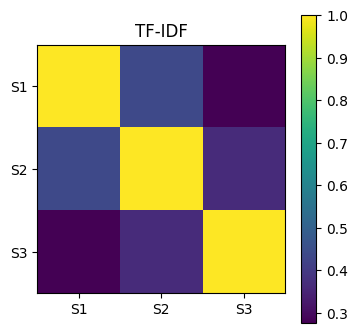

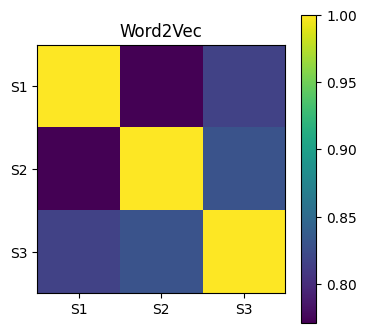

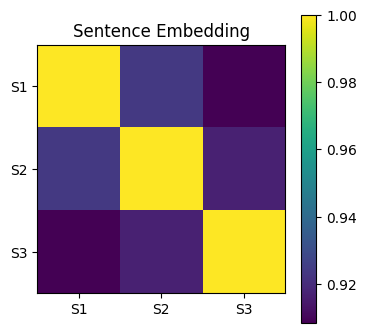

In [45]:
# ==========================================
# Cell 42 - Similarity Heatmaps
# ==========================================

import matplotlib.pyplot as plt

titles = [
    "TF-IDF",
    "Word2Vec",
    "Sentence Embedding"
]

matrices = [
    tfidf_similarity,
    w2v_similarity,
    embedding_similarity
]

for title, matrix in zip(titles, matrices):

    plt.figure(figsize=(4,4))

    plt.imshow(matrix)

    plt.colorbar()

    plt.xticks(range(3), ["S1","S2","S3"])
    plt.yticks(range(3), ["S1","S2","S3"])

    plt.title(title)

    plt.show()

In [46]:
# ==========================================
# Cell 43 - Final Comparison
# ==========================================

print("========== Final Comparison ==========\n")

print("TF-IDF")
print("- Sparse Representation")
print("- Sensitive to exact words")
print("- Weak semantic understanding\n")

print("Word2Vec")
print("- Dense Representation")
print("- Captures semantic relationships")
print("- Excellent after SVD\n")

print("Sentence Embedding")
print("- Understands sentence meaning")
print("- Best semantic representation")
print("- Most suitable for sentence similarity")

========== Final Comparison ==========

TF-IDF
- Sparse Representation
- Sensitive to exact words
- Weak semantic understanding

Word2Vec
- Dense Representation
- Captures semantic relationships
- Excellent after SVD

Sentence Embedding
- Understands sentence meaning
- Best semantic representation
- Most suitable for sentence similarity
